# Classification automatique des réclamations clients

**Pipeline** : EDA -> nettoyage -> déduplication -> split stratifié (catégorie x langue) -> **Logistic Regression (TF-IDF)** -> **DistilBERT multilingue (fine-tuning)** -> évaluation comparative (globale + par langue) -> analyse des erreurs.

Notebook pensé pour **Google Colab** (GPU recommandé : `Exécution > Modifier le type d'exécution > T4 GPU`).

> Ce notebook ne couvre que Logistic Regression et DistilBERT (LinearSVC a été retiré, écart non significatif avec LR sur les tests précédents).

## 1. Installation des dépendances

In [1]:
# transformers/datasets/accelerate ne sont pas preinstalles sur Colab ; torch et scikit-learn le sont deja.
!pip install -q langdetect statsmodels transformers datasets accelerate

## 2. Setup : imports, seed, configuration

In [2]:
import warnings
warnings.filterwarnings("ignore")

import json
import logging
import os
import random
import re
import time
import unicodedata
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    classification_report, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.utils.class_weight import compute_class_weight

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)-8s | %(message)s")
logger = logging.getLogger("reclamations")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

In [3]:
!pip uninstall -y torchvision

In [4]:
# --- Configuration centralisee (toutes les constantes du pipeline ici) ---

@dataclass(frozen=True)
class Config:
    seed: int = 42

    raw_path: Path = Path("/content/reclamations_categorie_finale_v3.csv")
    interim_dir: Path = Path("/content/data/interim")
    processed_dir: Path = Path("/content/data/processed")
    models_dir: Path = Path("/content/models")
    reports_dir: Path = Path("/content/reports")

    text_col: str = "texte"
    target_col: str = "categorie_finale"
    excluded_cols: tuple = ("ville", "montant", "montant_num")

    test_size: float = 0.15
    val_size: float = 0.15
    min_stratum_size_warning: int = 30

    near_dup_similarity_threshold: float = 0.92

    tfidf_ngram_range: tuple = (1, 2)
    tfidf_min_df: int = 2
    tfidf_max_features: int = 30000

CFG = Config()
for d in (CFG.interim_dir, CFG.processed_dir, CFG.models_dir, CFG.reports_dir, CFG.reports_dir / "figures"):
    d.mkdir(parents=True, exist_ok=True)

np.random.seed(CFG.seed)
random.seed(CFG.seed)

logger.info("Configuration chargee. Seed=%s", CFG.seed)

## 3. Chargement des données

Deux options : uploader le CSV directement (widget ci-dessous), ou le lire depuis Google Drive (décommenter la cellule suivante).

In [5]:
from google.colab import files

CFG.raw_path.parent.mkdir(parents=True, exist_ok=True)
uploaded = files.upload()  # selectionnez votre fichier .csv (colonnes attendues : texte, categorie_finale)
uploaded_name = next(iter(uploaded))
Path(uploaded_name).rename(CFG.raw_path)
print(f"Fichier enregistre : {CFG.raw_path}")

Saving reclamations_categorie_finale_v3.csv to reclamations_categorie_finale_v3 (1).csv
Fichier enregistre : /content/reclamations_categorie_finale_v3.csv


In [6]:
df = pd.read_csv(CFG.raw_path)
logger.info("Donnees chargees : %d lignes, %d colonnes", *df.shape)
df.head(3)

,texte,categorie_finale
0,"Concernant mon colis TRK-5645, qui devait être...",Livraison / Point relais
1,"Pour la commande TRK-3896, j'ai commandé un ar...",Livraison / Point relais
2,"Concernant mon colis TRK-7617, réceptionné à P...",Sinistre colis


## 4. EDA rapide

In [7]:
print("Dimensions :", df.shape)
print()
print("Valeurs manquantes (%) :")
print((df.isnull().mean() * 100).round(2))
print()
print(f"Doublons exacts (texte) : {df[CFG.text_col].duplicated().sum()}")

Dimensions : (2961, 2)

Valeurs manquantes (%) :
texte               0.0
categorie_finale    0.0
dtype: float64

Doublons exacts (texte) : 0


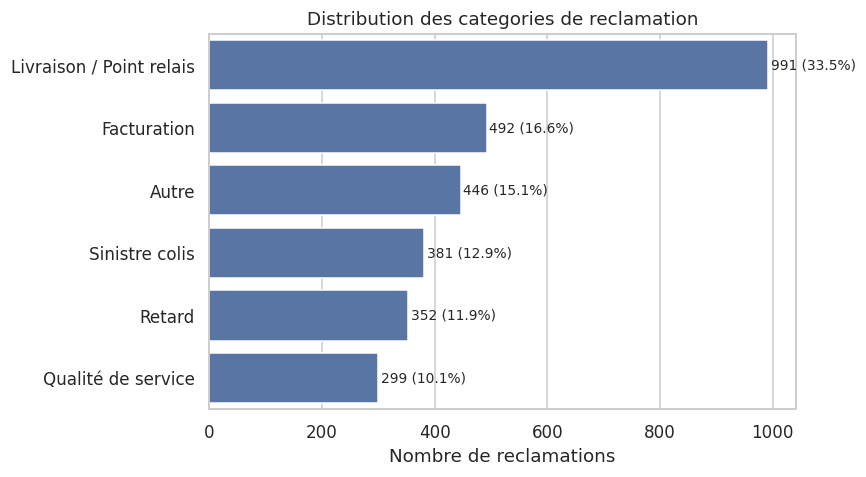

Ratio de desequilibre (classe majoritaire / minoritaire) : 3.3x


In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = df[CFG.target_col].value_counts().index
sns.countplot(data=df, y=CFG.target_col, order=order, ax=ax)
ax.set_title("Distribution des categories de reclamation")
ax.set_xlabel("Nombre de reclamations")
ax.set_ylabel("")
for i, cat in enumerate(order):
    n = (df[CFG.target_col] == cat).sum()
    ax.text(n + 5, i, f"{n} ({n/len(df)*100:.1f}%)", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(CFG.reports_dir / "figures" / "distribution_categories.png", bbox_inches="tight")
plt.show()

ratio_desequilibre = df[CFG.target_col].value_counts().max() / df[CFG.target_col].value_counts().min()
print(f"Ratio de desequilibre (classe majoritaire / minoritaire) : {ratio_desequilibre:.1f}x")

### 4.1 Détection de la langue

In [9]:
from langdetect import DetectorFactory, detect

DetectorFactory.seed = CFG.seed  # rend langdetect deterministe

def detect_lang_safe(text: str) -> str:
    """Detecte la langue d'un texte, avec repli robuste sur cas degeneres."""
    if not isinstance(text, str) or len(text.strip()) < 3:
        return "unknown"
    try:
        lang = detect(text)
    except Exception:
        return "unknown"
    return lang if lang in ("fr", "en") else "other"

df["langue"] = df[CFG.text_col].apply(detect_lang_safe)
print(df["langue"].value_counts())
print(f"\n% anglais : {(df['langue']=='en').mean()*100:.1f}%")

langue
fr    2125
en     836
Name: count, dtype: int64

% anglais : 28.2%


Repartition des categories selon la langue (%) :


langue,en,fr
categorie_finale,,
Autre,21.4,12.6
Facturation,12.7,18.2
Livraison / Point relais,11.7,42.0
Qualité de service,21.3,5.7
Retard,24.9,6.8
Sinistre colis,8.0,14.8


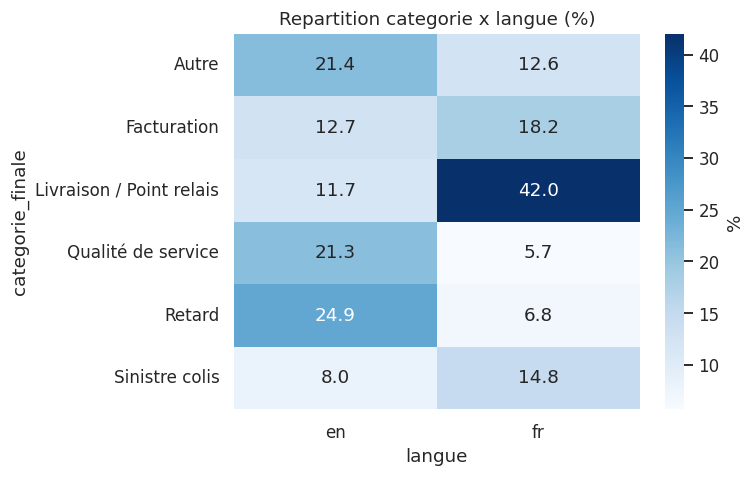

In [10]:
crosstab = pd.crosstab(df[CFG.target_col], df["langue"], normalize="columns") * 100
print("Repartition des categories selon la langue (%) :")
display(crosstab.round(1))

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(crosstab, annot=True, fmt=".1f", cmap="Blues", ax=ax, cbar_kws={"label": "%"})
ax.set_title("Repartition categorie x langue (%)")
plt.tight_layout()
plt.savefig(CFG.reports_dir / "figures" / "categorie_x_langue.png", bbox_inches="tight")
plt.show()

### 4.2 Vérification des risques de fuite (montant / tracking)

In [11]:
AMOUNT_PATTERN = re.compile(r"\d+[\.,]?\d*\s?(?:€|eur|euros?)", flags=re.IGNORECASE)
TRACKING_PATTERN_EDA = re.compile(r"\bTRK-\w+\b", flags=re.IGNORECASE)

df["montant_detecte_texte"] = df[CFG.text_col].str.contains(AMOUNT_PATTERN, regex=True)
presence_montant = df.groupby(CFG.target_col)["montant_detecte_texte"].apply(lambda x: x.mean() * 100)
display(pd.DataFrame({"% montant mentionne dans le texte": presence_montant}).round(1))

tracking_in_text = df[CFG.text_col].str.contains(TRACKING_PATTERN_EDA, regex=True)
print(f"% de textes contenant un numero de tracking (motif TRK-xxxx) : {tracking_in_text.mean()*100:.1f}%")
print("-> masquage systematique de ce pattern en pretraitement (aucune valeur semantique retenue).")

,% montant mentionne dans le texte
categorie_finale,
Autre,4.3
Facturation,80.9
Livraison / Point relais,4.5
Qualité de service,7.7
Retard,3.4
Sinistre colis,89.8


% de textes contenant un numero de tracking (motif TRK-xxxx) : 98.4%
-> masquage systematique de ce pattern en pretraitement (aucune valeur semantique retenue).


## 5. Nettoyage et prétraitement

In [12]:
TRACKING_PATTERN = re.compile(r"\bTRK-\w+\b", flags=re.IGNORECASE)
MULTI_SPACE_PATTERN = re.compile(r"\s+")
CENSORSHIP_PATTERN = re.compile(r"\*{2,}")

def _base_clean(text: str) -> str:
    """Nettoyage structurel commun aux deux pipelines (pas de perte de signal semantique)."""
    text = unicodedata.normalize("NFKC", str(text))
    text = TRACKING_PATTERN.sub("__TRACKING__", text)
    text = CENSORSHIP_PATTERN.sub(" __CENSURE__ ", text)
    text = MULTI_SPACE_PATTERN.sub(" ", text).strip()
    return text

def clean_text_transformer(text: str) -> str:
    """Nettoyage minimal pour DistilBERT : casse/ponctuation preservees (signal utile au tokenizer BPE)."""
    return _base_clean(text)

def clean_text_classic(text: str) -> str:
    """Nettoyage appuye pour TF-IDF : lowercase, ponctuation isolee retiree."""
    text = _base_clean(text)
    text = text.lower()
    text = re.sub(r"[^\w\s_]", " ", text, flags=re.UNICODE)
    text = MULTI_SPACE_PATTERN.sub(" ", text).strip()
    return text

df["texte_transformer"] = df[CFG.text_col].apply(clean_text_transformer)
df["texte_classic"] = df[CFG.text_col].apply(clean_text_classic)
df[[CFG.text_col, "texte_classic", "texte_transformer"]].head(3)

,texte,texte_classic,texte_transformer
0,"Concernant mon colis TRK-5645, qui devait être...",concernant mon colis __tracking__ qui devait ê...,"Concernant mon colis __TRACKING__, qui devait ..."
1,"Pour la commande TRK-3896, j'ai commandé un ar...",pour la commande __tracking__ j ai commandé un...,"Pour la commande __TRACKING__, j'ai commandé u..."
2,"Concernant mon colis TRK-7617, réceptionné à P...",concernant mon colis __tracking__ réceptionné ...,"Concernant mon colis __TRACKING__, réceptionné..."


## 6. Détection et suppression des quasi-doublons

In [13]:
dedup_vectorizer = TfidfVectorizer(max_features=5000)
X_dedup = dedup_vectorizer.fit_transform(df["texte_classic"])

def find_near_duplicates(X, threshold: float, block_size: int = 500):
    """Similarite cosinus calculee par blocs pour eviter une matrice n x n trop volumineuse en memoire."""
    n = X.shape[0]
    pairs = []
    for start in range(0, n, block_size):
        end = min(start + block_size, n)
        sim_block = cosine_similarity(X[start:end], X)
        for local_i, global_i in enumerate(range(start, end)):
            row = sim_block[local_i]
            row[global_i] = 0
            candidates = np.where(row >= threshold)[0]
            for j in candidates:
                if j > global_i:
                    pairs.append((global_i, j, row[j]))
    return pairs

near_dup_pairs = find_near_duplicates(X_dedup, CFG.near_dup_similarity_threshold)
print(f"Paires quasi-dupliquees detectees (seuil={CFG.near_dup_similarity_threshold}) : {len(near_dup_pairs)}")

indices_to_drop = sorted({j for _, j, _ in near_dup_pairs})
df_clean = df.drop(index=indices_to_drop).reset_index(drop=True)
print(f"Dataset : {len(df)} -> {len(df_clean)} lignes apres deduplication")
df_clean.to_csv(CFG.interim_dir / "reclamations_dedup.csv", index=False)

Paires quasi-dupliquees detectees (seuil=0.92) : 158
Dataset : 2961 -> 2814 lignes apres deduplication


## 7. Split stratifié conjoint catégorie x langue

In [14]:
df_clean["strate"] = df_clean[CFG.target_col] + "__" + df_clean["langue"]

strata_counts = df_clean["strate"].value_counts()
small_strata = strata_counts[strata_counts < CFG.min_stratum_size_warning]
if len(small_strata):
    logger.warning("Strates avec moins de %d exemples : %s", CFG.min_stratum_size_warning, dict(small_strata))

train_val_df, test_df = train_test_split(
    df_clean, test_size=CFG.test_size, stratify=df_clean["strate"], random_state=CFG.seed,
)
val_relative_size = CFG.val_size / (1 - CFG.test_size)
train_df, val_df = train_test_split(
    train_val_df, test_size=val_relative_size, stratify=train_val_df["strate"], random_state=CFG.seed,
)
print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

def strate_proportions(d):
    return (d["strate"].value_counts(normalize=True) * 100).round(2)

control_table = pd.DataFrame({
    "train": strate_proportions(train_df), "val": strate_proportions(val_df), "test": strate_proportions(test_df),
}).fillna(0.0)
display(control_table)

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    d.to_csv(CFG.processed_dir / f"{name}.csv", index=False)
logger.info("Splits sauvegardes dans %s", CFG.processed_dir)

Train : 1969 | Val : 422 | Test : 423


,train,val,test
strate,,,
Autre__en,6.04,5.92,6.15
Autre__fr,9.24,9.24,9.22
Facturation__en,2.03,2.13,2.13
Facturation__fr,13.56,13.51,13.48
Livraison / Point relais__en,3.20,3.08,3.07
Livraison / Point relais__fr,30.68,30.81,30.73
Qualité de service__en,5.99,5.92,5.91
Qualité de service__fr,4.32,4.27,4.26
Retard__en,6.70,6.87,6.86


## 8. Poids de classe (class weighting)

In [15]:
classes = sorted(train_df[CFG.target_col].unique())
class_weights = compute_class_weight(class_weight="balanced", classes=np.array(classes), y=train_df[CFG.target_col])
class_weight_dict = dict(zip(classes, class_weights))

for c, w in sorted(class_weight_dict.items(), key=lambda x: -x[1]):
    print(f"  {c:30s} -> {w:.3f}")

  Qualité de service             -> 1.617
  Retard                         -> 1.415
  Sinistre colis                 -> 1.267
  Autre                          -> 1.090
  Facturation                    -> 1.069
  Livraison / Point relais       -> 0.492


## 9. Fonctions d'évaluation partagées (LR et DistilBERT)

In [16]:
def evaluate_predictions(y_true, y_pred, langues, model_name: str) -> dict:
    """Metriques globales + ventilees par langue, meme format pour tous les modeles."""
    results = {"model": model_name}
    results["global"] = {
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }
    results["par_langue"] = {}
    langues = pd.Series(langues).reset_index(drop=True)
    y_true_s = pd.Series(y_true).reset_index(drop=True)
    y_pred_s = pd.Series(y_pred).reset_index(drop=True)
    for lang in ["fr", "en"]:
        mask = langues == lang
        if mask.sum() == 0:
            continue
        results["par_langue"][lang] = {
            "n": int(mask.sum()),
            "f1_macro": f1_score(y_true_s[mask], y_pred_s[mask], average="macro", zero_division=0),
        }
    return results

def print_evaluation(results: dict) -> None:
    print(f"=== {results['model']} ===")
    print(f"F1-macro global     : {results['global']['f1_macro']:.4f}")
    print(f"F1-weighted global  : {results['global']['f1_weighted']:.4f}")
    print(f"Balanced accuracy   : {results['global']['balanced_accuracy']:.4f}")
    for lang, m in results["par_langue"].items():
        print(f"F1-macro ({lang}, n={m['n']:4d}) : {m['f1_macro']:.4f}")

def plot_confusion(y_true, y_pred, labels, title: str, save_name: str) -> None:
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(CFG.reports_dir / "figures" / save_name, bbox_inches="tight")
    plt.show()

## 10. Baseline : TF-IDF + Logistic Regression

In [17]:
tfidf = TfidfVectorizer(
    ngram_range=CFG.tfidf_ngram_range, min_df=CFG.tfidf_min_df,
    max_features=CFG.tfidf_max_features, sublinear_tf=True,
)
X_train = tfidf.fit_transform(train_df["texte_classic"])
X_val = tfidf.transform(val_df["texte_classic"])
X_test = tfidf.transform(test_df["texte_classic"])

y_train, y_val, y_test = train_df[CFG.target_col], val_df[CFG.target_col], test_df[CFG.target_col]

print(f"Vocabulaire TF-IDF : {len(tfidf.vocabulary_)} termes")
print(f"X_train shape : {X_train.shape}")

Vocabulaire TF-IDF : 25892 termes
X_train shape : (1969, 25892)


In [18]:
log_reg = LogisticRegression(class_weight="balanced", max_iter=3000, random_state=CFG.seed, n_jobs=-1)
log_reg.fit(X_train, y_train)

y_val_pred_lr = log_reg.predict(X_val)
print_evaluation(evaluate_predictions(y_val, y_val_pred_lr, val_df["langue"], "Logistic Regression (val)"))

=== Logistic Regression (val) ===
F1-macro global     : 0.7872
F1-weighted global  : 0.8126
Balanced accuracy   : 0.7856
F1-macro (fr, n= 312) : 0.7908
F1-macro (en, n= 110) : 0.5506


In [19]:
print(classification_report(y_val, y_val_pred_lr, zero_division=0))

                          precision    recall  f1-score   support

                   Autre       0.71      0.66      0.68        64
             Facturation       0.79      0.85      0.82        66
Livraison / Point relais       0.89      0.90      0.89       143
      Qualité de service       0.56      0.67      0.61        43
                  Retard       0.83      0.80      0.82        50
          Sinistre colis       0.98      0.84      0.90        56

                accuracy                           0.81       422
               macro avg       0.79      0.79      0.79       422
            weighted avg       0.82      0.81      0.81       422



## 11. Validation croisée + recherche d'hyperparamètres (Logistic Regression)

`max_iter` porté à 5000 (au lieu de 2000) pour laisser `saga` converger sur la grille L1/L2 complète.

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=CFG.seed)

cv_scores_lr = cross_val_score(
    LogisticRegression(class_weight="balanced", max_iter=5000, random_state=CFG.seed),
    X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1,
)
print(f"LR - F1-macro CV : {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")

LR - F1-macro CV : 0.7906 (+/- 0.0171)


In [21]:
param_grid_lr = {"C": [0.01, 0.1, 1.0, 3.0, 10.0], "penalty": ["l1", "l2"]}
grid_lr = GridSearchCV(
    LogisticRegression(class_weight="balanced", max_iter=5000, random_state=CFG.seed, solver="saga"),
    param_grid_lr, cv=cv, scoring="f1_macro", n_jobs=-1,
)
grid_lr.fit(X_train, y_train)
print(f"Meilleurs hyperparametres (LR) : {grid_lr.best_params_} -> F1-macro CV = {grid_lr.best_score_:.4f}")

best_lr = grid_lr.best_estimator_

Meilleurs hyperparametres (LR) : {'C': 10.0, 'penalty': 'l1'} -> F1-macro CV = 0.8861


In [22]:
import joblib

joblib.dump(tfidf, CFG.models_dir / "tfidf_vectorizer.joblib")
joblib.dump(best_lr, CFG.models_dir / "logistic_regression.joblib")
logger.info("Modele LR et vectorizer sauvegardes dans %s", CFG.models_dir)

## 12. Fine-tuning DistilBERT multilingue

**Modèle** : `distilbert-base-multilingual-cased` (gère nativement FR+EN dans le même espace d'embeddings, y compris le code-switching).

**Méthodologie reprise d'un pipeline DistilCamemBERT plus abouti** (voir diagnostic précédent : val F1=0.850/0.816 selon les runs, mais test F1=0.774/0.764 -- écart non expliqué par un simple réglage d'époques) :

- **Validation croisée stratifiée à 5 plis sur le train set** (au lieu d'un seul split train/val fixe) : donne une estimation de performance moins sensible au bruit d'un petit échantillon de validation, et un écart-type entre plis qui quantifie directement l'instabilité du modèle sur ce volume de données.
- **Learning rates discriminants par groupe de couches** : les couches basses (embeddings, connaissances linguistiques génériques) sont modifiées très peu ; la tête de classification (initialisée aléatoirement) apprend vite. Limite le risque d'écraser le pré-entraînement avec seulement ~2000 exemples.
- **Label smoothing + gradient clipping** : régularisations supplémentaires pertinentes sur petit volume.
- **Sélection du meilleur modèle sur `eval_loss`** (pas `f1_macro`, qui s'est avéré bruité et trompeur sur un val set de 422 exemples lors des runs précédents).
- **Test set toujours tenu à l'écart** : la CV et le refit final n'utilisent que train+val ; `test_df` ne sert qu'à la comparaison finale LR vs BERT (section 13), inchangée.

Sur Colab, activez un runtime GPU (`Exécution > Modifier le type d'exécution > T4 GPU`) pour un temps d'entraînement raisonnable.

In [23]:
import torch
print("GPU disponible :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU utilise :", torch.cuda.get_device_name(0))
else:
    print("-> Aucun GPU detecte : l'entrainement tournera sur CPU (beaucoup plus lent).")

GPU disponible : True
GPU utilise : Tesla T4


In [24]:
MODEL_NAME = "distilbert-base-multilingual-cased"
# Revision epinglee (hash de commit) recommandee en production ; "main" suit la derniere version du Hub.
MODEL_REVISION = "main"  # TODO: remplacer par un hash de commit precis avant tout usage en production
MAX_LENGTH = 256
BATCH_SIZE = 16
NUM_EPOCHS = 8            # cf. diagnostic precedent : la val loss se stabilise vers l'epoque 7-8 a lr=1e-5

# --- Learning rates discriminants (discriminative fine-tuning) ---
# Couches basses (embeddings + premieres couches) : representations linguistiques generiques
# deja bien apprises au pre-entrainement -> les modifier tres peu evite le catastrophic
# forgetting avec seulement ~2000 exemples de train. Tete de classification : initialisee
# aleatoirement, doit apprendre vite. LR croissant du bas vers le haut du reseau.
LR_HEAD = 5e-5
LR_TOP_LAYERS = 2e-5
LR_BASE_LAYERS = 5e-6
NUM_TOP_LAYERS = 2

# --- Regularisation ---
WEIGHT_DECAY = 0.05
LABEL_SMOOTHING = 0.1
WARMUP_RATIO = 0.1
MAX_GRAD_NORM = 1.0
EARLY_STOPPING_PATIENCE = 2

N_SPLITS_CV = 5           # nombre de plis pour le diagnostic de stabilite

os.environ.setdefault("HF_HUB_DOWNLOAD_TIMEOUT", "120")

def load_with_retries(loader_fn, *args, max_retries: int = 4, initial_backoff: float = 5.0, **kwargs):
    """Retry + backoff exponentiel pour les appels from_pretrained (pannes reseau transitoires)."""
    last_exc = None
    for attempt in range(1, max_retries + 1):
        try:
            return loader_fn(*args, **kwargs)
        except Exception as exc:
            last_exc = exc
            if attempt == max_retries:
                break
            wait = initial_backoff * (2 ** (attempt - 1))
            logger.warning("Echec chargement (tentative %d/%d) : %s -- nouvel essai dans %.0fs",
                            attempt, max_retries, type(exc).__name__, wait)
            time.sleep(wait)
    raise RuntimeError(
        f"Impossible de charger '{MODEL_NAME}' depuis le Hugging Face Hub apres {max_retries} tentatives."
    ) from last_exc

In [25]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from datasets import Dataset
import torch.nn as nn
import math

label2id = {c: i for i, c in enumerate(classes)}
id2label = {i: c for c, i in label2id.items()}

tokenizer = load_with_retries(AutoTokenizer.from_pretrained, MODEL_NAME, revision=MODEL_REVISION)

def to_hf_dataset(d: pd.DataFrame) -> Dataset:
    """Convertit un DataFrame en Dataset HF tokenise. Pas de padding ici : gere
    dynamiquement par le DataCollator au moment de construire chaque batch (plus efficace
    qu'un padding fixe a MAX_LENGTH systematiquement)."""
    ds = Dataset.from_dict({
        "text": d["texte_transformer"].tolist(),
        "label": [label2id[c] for c in d[CFG.target_col]],
    })
    ds = ds.map(lambda batch: tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH), batched=True)
    ds = ds.rename_column("label", "labels")
    ds = ds.remove_columns(["text"])
    ds.set_format("torch")
    return ds

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

ds_train = to_hf_dataset(train_df)
ds_val = to_hf_dataset(val_df)
ds_test = to_hf_dataset(test_df)

class_weights_tensor_full = torch.tensor(
    [class_weight_dict[id2label[i]] for i in range(len(classes))], dtype=torch.float,
)

Map:   0%|          | 0/1969 [00:00<?, ? examples/s]

Map:   0%|          | 0/422 [00:00<?, ? examples/s]

Map:   0%|          | 0/423 [00:00<?, ? examples/s]

In [26]:
def compute_metrics(eval_pred) -> dict:
    """F1-macro rapporte pour le suivi humain, mais PAS utilise comme critere de selection
    du meilleur modele (cf. diagnostic precedent : bruite sur un petit val set, a mene a
    retenir un modele sur-ajuste). Le critere de selection reste eval_loss (cf. TrainingArguments)."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(labels, preds) if len(set(labels)) > 1 else 0.0,
    }


def build_grouped_optimizer(model: nn.Module, class_weights: torch.Tensor) -> AdamW:
    """AdamW a 6 groupes de parametres : {tete, N dernieres couches, reste+embeddings} x
    {avec weight_decay, sans}. Pattern de nommage generique "layer.N." (regex dans le code)
    pour couvrir
    a la fois les architectures type BERT/RoBERTa ('encoder.layer.N') et DistilBERT
    ('transformer.layer.N'). La tete de classification de DistilBERT comprend 2 modules
    ('pre_classifier' ET 'classifier', contrairement a RoBERTa/CamemBERT qui n'ont que
    'classifier') -- les deux sont donc inclus dans le bucket 'head'."""
    num_layers = getattr(model.config, "num_hidden_layers", None) or getattr(model.config, "n_layers")
    top_layer_start = num_layers - NUM_TOP_LAYERS

    no_decay_keywords = ("bias", "LayerNorm.weight", "layer_norm.weight")
    head_prefixes = ("classifier", "pre_classifier")
    layer_pattern = re.compile(r"\.layer\.(\d+)\.")

    buckets = {
        "head_decay": [], "head_no_decay": [],
        "top_decay": [], "top_no_decay": [],
        "base_decay": [], "base_no_decay": [],
    }

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        no_decay = any(kw in name for kw in no_decay_keywords)
        if name.startswith(head_prefixes):
            bucket = "head_no_decay" if no_decay else "head_decay"
        else:
            match = layer_pattern.search(name)
            if match and int(match.group(1)) >= top_layer_start:
                bucket = "top_no_decay" if no_decay else "top_decay"
            else:
                bucket = "base_no_decay" if no_decay else "base_decay"
        buckets[bucket].append(param)

    lr_map = {"head": LR_HEAD, "top": LR_TOP_LAYERS, "base": LR_BASE_LAYERS}
    optimizer_grouped_parameters = []
    for bucket_name, params in buckets.items():
        if not params:
            continue
        group_key = bucket_name.split("_")[0]
        wd = 0.0 if "no_decay" in bucket_name else WEIGHT_DECAY
        optimizer_grouped_parameters.append({"params": params, "lr": lr_map[group_key], "weight_decay": wd})

    return AdamW(optimizer_grouped_parameters)


def build_model() -> AutoModelForSequenceClassification:
    return load_with_retries(
        AutoModelForSequenceClassification.from_pretrained,
        MODEL_NAME, num_labels=len(classes), id2label=id2label, label2id=label2id, revision=MODEL_REVISION,
    ).to("cuda" if torch.cuda.is_available() else "cpu")


def build_scheduler(optimizer, num_training_steps: int):
    num_warmup_steps = int(num_training_steps * WARMUP_RATIO)
    return get_linear_schedule_with_warmup(optimizer, num_warmup_steps=num_warmup_steps, num_training_steps=num_training_steps)


def make_weighted_trainer_class(class_weights: torch.Tensor):
    """Fabrique une classe Trainer avec loss ponderee par classe + label smoothing combines
    dans un seul CrossEntropyLoss (les deux sont des arguments natifs de nn.CrossEntropyLoss
    depuis torch>=1.10, pas besoin de les combiner manuellement)."""
    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            logits = outputs.logits
            loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device), label_smoothing=LABEL_SMOOTHING)
            loss = loss_fct(logits, labels)
            return (loss, outputs) if return_outputs else loss
    return WeightedTrainer

### 12.1 Diagnostic de stabilité : validation croisée à 5 plis (sur le train set uniquement)

Objectif : estimer la performance et sa variance sur ce volume de données, sans consommer le val/test set. Chaque pli reconstruit un modèle **neuf** (poids pré-entraînés + tête réinitialisée) pour éviter toute fuite d'un pli à l'autre.

In [27]:
from sklearn.model_selection import StratifiedKFold as StratifiedKFoldCV

skf = StratifiedKFoldCV(n_splits=N_SPLITS_CV, shuffle=True, random_state=CFG.seed)

X_cv = train_df["texte_transformer"].values
y_cv_strate = train_df["strate"].values  # stratification categorie x langue, coherente avec le split initial

fold_results = []

for fold_idx, (fold_train_idx, fold_val_idx) in enumerate(skf.split(X_cv, y_cv_strate), start=1):
    print(f"\n{'='*60}\nFOLD {fold_idx}/{N_SPLITS_CV}\n{'='*60}")

    fold_train_df = train_df.iloc[fold_train_idx].reset_index(drop=True)
    fold_val_df = train_df.iloc[fold_val_idx].reset_index(drop=True)

    fold_train_ds = to_hf_dataset(fold_train_df)
    fold_val_ds = to_hf_dataset(fold_val_df)

    fold_class_weights = torch.tensor(
        [class_weight_dict.get(id2label[i], 1.0) for i in range(len(classes))], dtype=torch.float,
    )

    fold_model = build_model()
    fold_optimizer = build_grouped_optimizer(fold_model, fold_class_weights)
    fold_steps_per_epoch = math.ceil(len(fold_train_ds) / BATCH_SIZE)
    fold_scheduler = build_scheduler(fold_optimizer, fold_steps_per_epoch * NUM_EPOCHS)

    fold_args = TrainingArguments(
        output_dir=str(CFG.models_dir / f"distilbert_cv_fold{fold_idx}"),
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        max_grad_norm=MAX_GRAD_NORM,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        save_total_limit=1,
        logging_strategy="epoch",
        fp16=torch.cuda.is_available(),
        seed=CFG.seed,
        report_to="none",
        disable_tqdm=False,
    )

    WeightedTrainerCV = make_weighted_trainer_class(fold_class_weights)
    fold_trainer = WeightedTrainerCV(
        model=fold_model, args=fold_args, train_dataset=fold_train_ds, eval_dataset=fold_val_ds,
        data_collator=data_collator, compute_metrics=compute_metrics,
        optimizers=(fold_optimizer, fold_scheduler),
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
    )
    fold_trainer.train()
    fold_metrics = fold_trainer.evaluate()

    fold_val_langues = fold_val_df["langue"].reset_index(drop=True)
    fold_logits = fold_trainer.predict(fold_val_ds).predictions
    fold_preds = [id2label[i] for i in np.argmax(fold_logits, axis=1)]
    fold_eval = evaluate_predictions(fold_val_df[CFG.target_col], fold_preds, fold_val_langues, f"fold_{fold_idx}")

    print(f"Fold {fold_idx} -> eval_loss={fold_metrics['eval_loss']:.4f} | f1_macro={fold_metrics['eval_f1_macro']:.4f}")

    fold_results.append({
        "fold": fold_idx,
        "eval_loss": fold_metrics["eval_loss"],
        "f1_macro": fold_eval["global"]["f1_macro"],
        "f1_macro_fr": fold_eval["par_langue"].get("fr", {}).get("f1_macro", np.nan),
        "f1_macro_en": fold_eval["par_langue"].get("en", {}).get("f1_macro", np.nan),
    })

    del fold_model, fold_trainer, fold_optimizer, fold_scheduler
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


FOLD 1/5


Map:   0%|          | 0/1575 [00:00<?, ? examples/s]

Map:   0%|          | 0/394 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,F1 Macro,Balanced Accuracy
0.758914,0.962215,8,0.746118,0.753044


Fold 5 -> eval_loss=0.9622 | f1_macro=0.7461


In [28]:
cv_results_df = pd.DataFrame(fold_results).set_index("fold")
print("Resultats par pli :")
display(cv_results_df.round(4))

cv_summary = cv_results_df.agg(["mean", "std"]).round(4)
print("\nResume (moyenne / ecart-type sur les 5 plis) :")
display(cv_summary)

print(
    "\n--- Diagnostic de stabilite ---\n"
    f"F1-macro global : {cv_summary.loc['mean', 'f1_macro']:.4f} +/- {cv_summary.loc['std', 'f1_macro']:.4f}\n"
    f"F1-macro FR     : {cv_summary.loc['mean', 'f1_macro_fr']:.4f} +/- {cv_summary.loc['std', 'f1_macro_fr']:.4f}\n"
    f"F1-macro EN     : {cv_summary.loc['mean', 'f1_macro_en']:.4f} +/- {cv_summary.loc['std', 'f1_macro_en']:.4f}\n"
    "Un ecart-type eleve (> 0.03-0.05) signale une forte sensibilite au split -- a rapporter "
    "tel quel, pas a masquer. C'est cet indicateur (absent du pipeline precedent) qui aurait "
    "signale en amont le risque de non-generalisation observe entre val et test."
)

Resultats par pli :


,eval_loss,f1_macro,f1_macro_fr,f1_macro_en
fold,,,,
1,0.9870,0.7527,0.7506,0.6840
2,1.0131,0.7448,0.7962,0.6240
3,0.9244,0.7617,0.7832,0.6808
4,1.0449,0.7154,0.7307,0.6755
5,0.9622,0.7461,0.7539,0.7182



Resume (moyenne / ecart-type sur les 5 plis) :


,eval_loss,f1_macro,f1_macro_fr,f1_macro_en
mean,0.9863,0.7442,0.7629,0.6765
std,0.0463,0.0174,0.0264,0.0338



--- Diagnostic de stabilite ---
F1-macro global : 0.7442 +/- 0.0174
F1-macro FR     : 0.7629 +/- 0.0264
F1-macro EN     : 0.6765 +/- 0.0338
Un ecart-type eleve (> 0.03-0.05) signale une forte sensibilite au split -- a rapporter tel quel, pas a masquer. C'est cet indicateur (absent du pipeline precedent) qui aurait signale en amont le risque de non-generalisation observe entre val et test.


### 12.2 Entraînement final (train set complet) + sauvegarde

Une fois la stabilité vérifiée par la CV, on entraîne le modèle de production sur `train_df` complet, avec `val_df` comme critère d'arrêt (`eval_loss`, cohérent avec la CV) -- `test_df` reste réservé à la comparaison finale (section 13).

In [29]:
final_model = build_model()
final_optimizer = build_grouped_optimizer(final_model, class_weights_tensor_full)
final_steps_per_epoch = math.ceil(len(ds_train) / BATCH_SIZE)
final_scheduler = build_scheduler(final_optimizer, final_steps_per_epoch * NUM_EPOCHS)

final_training_args = TrainingArguments(
    output_dir=str(CFG.models_dir / "distilbert_checkpoints"),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    max_grad_norm=MAX_GRAD_NORM,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",   # pas f1_macro (cf. diagnostic precedent)
    greater_is_better=False,
    save_total_limit=1,
    logging_strategy="epoch",
    fp16=torch.cuda.is_available(),
    seed=CFG.seed,
    report_to="none",
)

WeightedTrainer = make_weighted_trainer_class(class_weights_tensor_full)
trainer = WeightedTrainer(
    model=final_model,
    args=final_training_args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    optimizers=(final_optimizer, final_scheduler),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)

trainer.train()
trainer.save_model(str(CFG.models_dir / "distilbert_final"))
tokenizer.save_pretrained(str(CFG.models_dir / "distilbert_final"))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Macro,Balanced Accuracy
1,1.694945,1.330683,0.526254,0.568682
2,1.149935,1.026389,0.706838,0.726505
3,0.971976,0.964124,0.748964,0.764267
4,0.891155,0.925854,0.774554,0.784466
5,0.820608,0.901508,0.789081,0.799195
6,0.776914,0.901937,0.787053,0.795625
7,0.743509,0.894843,0.789502,0.798072
8,0.716723,0.896379,0.795116,0.805063


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/models/distilbert_final/tokenizer_config.json',
 '/content/models/distilbert_final/tokenizer.json')

In [30]:
val_preds_logits = trainer.predict(ds_val).predictions
y_val_pred_bert = [id2label[i] for i in np.argmax(val_preds_logits, axis=1)]
print_evaluation(evaluate_predictions(y_val, y_val_pred_bert, val_df["langue"], "DistilBERT multilingue (val)"))
print("\n-> A comparer a l'estimation CV ci-dessus : un ecart important suggererait encore une instabilite liee au split.")

=== DistilBERT multilingue (val) ===
F1-macro global     : 0.7895
F1-weighted global  : 0.8181
Balanced accuracy   : 0.7981
F1-macro (fr, n= 312) : 0.8253
F1-macro (en, n= 110) : 0.7058

-> A comparer a l'estimation CV ci-dessus : un ecart important suggererait encore une instabilite liee au split.


## 13. Évaluation comparative finale (test set)

In [31]:
y_test_pred_lr = best_lr.predict(X_test)
results_lr_test = evaluate_predictions(y_test, y_test_pred_lr, test_df["langue"], "Logistic Regression (test)")
print_evaluation(results_lr_test)

test_preds_logits = trainer.predict(ds_test).predictions
y_test_pred_bert = [id2label[i] for i in np.argmax(test_preds_logits, axis=1)]
results_bert_test = evaluate_predictions(y_test, y_test_pred_bert, test_df["langue"], "DistilBERT multilingue (test)")
print()
print_evaluation(results_bert_test)

final_results = [results_lr_test, results_bert_test]

=== Logistic Regression (test) ===
F1-macro global     : 0.8793
F1-weighted global  : 0.8967
Balanced accuracy   : 0.8813
F1-macro (fr, n= 312) : 0.8998
F1-macro (en, n= 111) : 0.7852



=== DistilBERT multilingue (test) ===
F1-macro global     : 0.7629
F1-weighted global  : 0.7882
Balanced accuracy   : 0.7728
F1-macro (fr, n= 312) : 0.7648
F1-macro (en, n= 111) : 0.6671


In [32]:
comparison_rows = []
for r in final_results:
    row = {
        "Modele": r["model"],
        "F1-macro global": r["global"]["f1_macro"],
        "F1-weighted global": r["global"]["f1_weighted"],
        "Balanced accuracy": r["global"]["balanced_accuracy"],
    }
    for lang, m in r["par_langue"].items():
        row[f"F1-macro ({lang})"] = m["f1_macro"]
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).round(4)
display(comparison_df)
comparison_df.to_csv(CFG.reports_dir / "comparaison_finale_modeles.csv", index=False)

,Modele,F1-macro global,F1-weighted global,Balanced accuracy,F1-macro (fr),F1-macro (en)
0,Logistic Regression (test),0.8793,0.8967,0.8813,0.8998,0.7852
1,DistilBERT multilingue (test),0.7629,0.7882,0.7728,0.7648,0.6671


## 14. Tests de significativité statistique et diagnostics complémentaires

In [33]:
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_pairwise(y_true, pred_a, pred_b, name_a: str, name_b: str) -> dict:
    """McNemar : compare deux modeles sur les memes exemples de test (donnees appariees)."""
    y_true = pd.Series(y_true).reset_index(drop=True)
    pred_a = pd.Series(pred_a).reset_index(drop=True)
    pred_b = pd.Series(pred_b).reset_index(drop=True)
    correct_a, correct_b = pred_a == y_true, pred_b == y_true
    both_correct = int((correct_a & correct_b).sum())
    only_a_correct = int((correct_a & ~correct_b).sum())
    only_b_correct = int((~correct_a & correct_b).sum())
    both_wrong = int((~correct_a & ~correct_b).sum())
    table = [[both_correct, only_a_correct], [only_b_correct, both_wrong]]
    n_discordant = only_a_correct + only_b_correct
    result = mcnemar(table, exact=(n_discordant < 25), correction=True)
    verdict = "SIGNIFICATIF (p<0.05)" if result.pvalue < 0.05 else "non significatif (p>=0.05)"
    print(f"=== McNemar : {name_a} vs {name_b} ===")
    print(f"  {name_a} correct seul : {only_a_correct}")
    print(f"  {name_b} correct seul : {only_b_correct}")
    print(f"  Desaccords totaux    : {n_discordant}")
    print(f"  statistic = {result.statistic:.4f} | p-value = {result.pvalue:.4f}")
    print(f"  -> {verdict}\n")
    return {"comparaison": f"{name_a} vs {name_b}", "only_a_correct": only_a_correct,
            "only_b_correct": only_b_correct, "statistic": result.statistic,
            "p_value": result.pvalue, "significatif": bool(result.pvalue < 0.05)}

mcnemar_result = mcnemar_pairwise(y_test, y_test_pred_lr, y_test_pred_bert, "LR", "BERT")

=== McNemar : LR vs BERT ===
  LR correct seul : 61
  BERT correct seul : 14
  Desaccords totaux    : 75
  statistic = 28.2133 | p-value = 0.0000
  -> SIGNIFICATIF (p<0.05)



In [34]:
def bootstrap_f1_macro(y_true, y_pred, langues=None, n_iter: int = 1000, seed: int = 42) -> dict:
    """F1-macro observe + IC95% bootstrap, global et par langue."""
    rng = np.random.default_rng(seed)
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)
    n = len(y_true)

    def _f1(idx):
        return f1_score(y_true.iloc[idx], y_pred.iloc[idx], average="macro", zero_division=0)

    boot_scores = np.array([_f1(rng.integers(0, n, n)) for _ in range(n_iter)])
    global_result = {
        "observed": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "ci_low": np.percentile(boot_scores, 2.5),
        "ci_high": np.percentile(boot_scores, 97.5),
        "std": boot_scores.std(),
    }
    result = {"global": global_result, "par_langue": {}}
    if langues is not None:
        langues = pd.Series(langues).reset_index(drop=True)
        for lang in ["fr", "en"]:
            mask_idx = np.where(langues == lang)[0]
            if len(mask_idx) == 0:
                continue
            n_lang = len(mask_idx)

            def _f1_lang(_, mask_idx=mask_idx, n_lang=n_lang):
                sampled = rng.choice(mask_idx, size=n_lang, replace=True)
                return f1_score(y_true.iloc[sampled], y_pred.iloc[sampled], average="macro", zero_division=0)

            boot_lang = np.array([_f1_lang(i) for i in range(n_iter)])
            result["par_langue"][lang] = {
                "n": n_lang,
                "observed": f1_score(y_true.iloc[mask_idx], y_pred.iloc[mask_idx], average="macro", zero_division=0),
                "ci_low": np.percentile(boot_lang, 2.5),
                "ci_high": np.percentile(boot_lang, 97.5),
                "std": boot_lang.std(),
            }
    return result

def print_bootstrap_result(model_name: str, result: dict) -> None:
    g = result["global"]
    print(f"=== {model_name} (bootstrap, IC95%, n_iter=1000) ===")
    print(f"  Global  : {g['observed']:.4f}  [{g['ci_low']:.4f} ; {g['ci_high']:.4f}]  (std={g['std']:.4f})")
    for lang, m in result["par_langue"].items():
        print(f"  {lang} (n={m['n']:3d}) : {m['observed']:.4f}  [{m['ci_low']:.4f} ; {m['ci_high']:.4f}]  (std={m['std']:.4f})")
    print()

predictions = {"LR": y_test_pred_lr, "BERT": y_test_pred_bert}
bootstrap_results = {}
for name, preds in predictions.items():
    bootstrap_results[name] = bootstrap_f1_macro(y_test, preds, test_df["langue"], n_iter=1000, seed=CFG.seed)
    print_bootstrap_result(name, bootstrap_results[name])

ra, rb = bootstrap_results["LR"]["global"], bootstrap_results["BERT"]["global"]
overlap = not (ra["ci_high"] < rb["ci_low"] or rb["ci_high"] < ra["ci_low"])
print("IC se chevauchent -> ecart NON concluant" if overlap else "IC disjoints -> ecart probablement reel")

=== LR (bootstrap, IC95%, n_iter=1000) ===
  Global  : 0.8793  [0.8404 ; 0.9098]  (std=0.0178)
  fr (n=312) : 0.8998  [0.8510 ; 0.9437]  (std=0.0231)
  en (n=111) : 0.7852  [0.6905 ; 0.8616]  (std=0.0436)

=== BERT (bootstrap, IC95%, n_iter=1000) ===
  Global  : 0.7629  [0.7177 ; 0.7993]  (std=0.0215)
  fr (n=312) : 0.7648  [0.7072 ; 0.8235]  (std=0.0291)
  en (n=111) : 0.6671  [0.5535 ; 0.7522]  (std=0.0508)

IC disjoints -> ecart probablement reel


In [35]:
def diagnose_class(y_true, predictions: dict, target_class: str) -> pd.DataFrame:
    """F1/precision/recall pour une classe isolee (un F1-macro global peut la masquer)."""
    y_true = pd.Series(y_true).reset_index(drop=True)
    rows = []
    for model_name, y_pred in predictions.items():
        y_pred = pd.Series(y_pred).reset_index(drop=True)
        rows.append({
            "modele": model_name, "classe": target_class,
            "precision": precision_score(y_true, y_pred, labels=[target_class], average="macro", zero_division=0),
            "recall": recall_score(y_true, y_pred, labels=[target_class], average="macro", zero_division=0),
            "f1": f1_score(y_true, y_pred, labels=[target_class], average="macro", zero_division=0),
            "n_exemples_reels": int((y_true == target_class).sum()),
        })
    result_df = pd.DataFrame(rows)
    print(f"=== Diagnostic classe '{target_class}' (isolee, pas macro-moyennee) ===")
    print(result_df.to_string(index=False))
    return result_df

diagnose_class(y_test, predictions, target_class="Autre")

=== Diagnostic classe 'Autre' (isolee, pas macro-moyennee) ===
modele classe  precision   recall       f1  n_exemples_reels
    LR  Autre   0.782051 0.938462 0.853147                65
  BERT  Autre   0.710526 0.830769 0.765957                65


,modele,classe,precision,recall,f1,n_exemples_reels
0,LR,Autre,0.782051,0.938462,0.853147,65
1,BERT,Autre,0.710526,0.830769,0.765957,65


In [36]:
def sample_for_langdetect_audit(df, text_col, lang_col, n_per_lang=40, seed=42):
    """Echantillon stratifie a verifier manuellement (colonne langue_correcte a remplir)."""
    rng = np.random.default_rng(seed)
    samples = []
    for lang in df[lang_col].unique():
        subset = df[df[lang_col] == lang]
        n = min(n_per_lang, len(subset))
        idx = rng.choice(subset.index, size=n, replace=False)
        samples.append(subset.loc[idx])
    audit_df = pd.concat(samples)[[text_col, lang_col]].reset_index(drop=True)
    audit_df = audit_df.rename(columns={lang_col: "langue_detectee"})
    audit_df["langue_correcte"] = ""
    audit_df["texte_court"] = audit_df[text_col].str.slice(0, 150)
    return audit_df[["texte_court", "langue_detectee", "langue_correcte"]]

audit_path = CFG.reports_dir / "audit_langdetect_a_completer.csv"
audit_df = sample_for_langdetect_audit(df, CFG.text_col, "langue", n_per_lang=40, seed=CFG.seed)
audit_df.to_csv(audit_path, index=False)
print(f"-> Completer manuellement la colonne 'langue_correcte' dans {audit_path}.")

-> Completer manuellement la colonne 'langue_correcte' dans /content/reports/audit_langdetect_a_completer.csv.


## 15. Analyse des erreurs

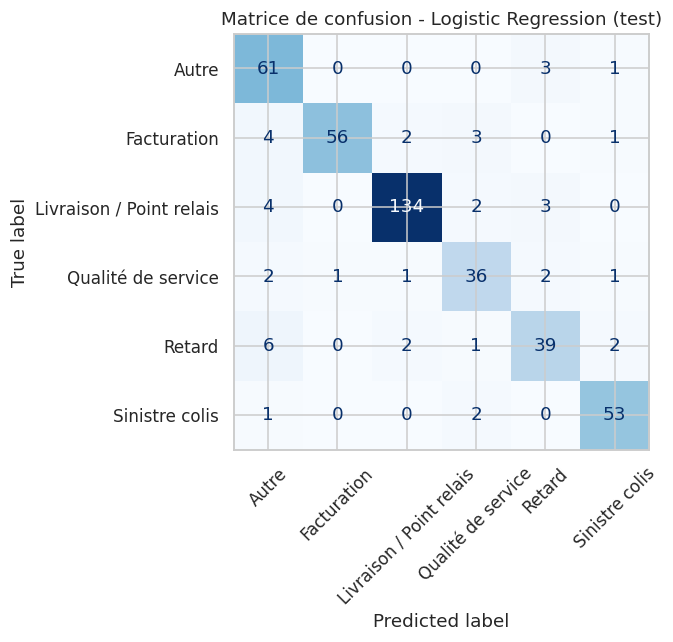

In [37]:
plot_confusion(y_test, y_test_pred_lr, classes, "Matrice de confusion - Logistic Regression (test)", "confusion_lr.png")

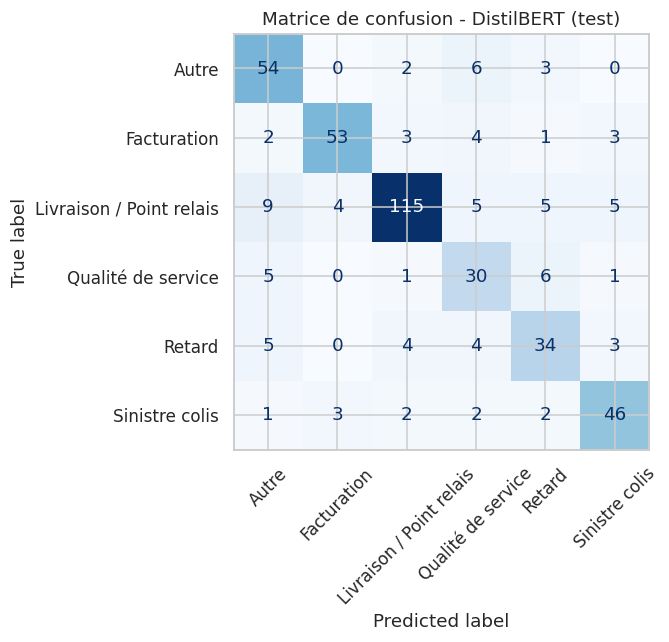

In [38]:
plot_confusion(y_test, y_test_pred_bert, classes, "Matrice de confusion - DistilBERT (test)", "confusion_bert.png")

In [39]:
errors_df = test_df.copy()
errors_df["prediction_lr"] = y_test_pred_lr
errors_df = errors_df[errors_df[CFG.target_col] != errors_df["prediction_lr"]]

print(f"Nombre d'erreurs (LR, test) : {len(errors_df)} / {len(test_df)} ({len(errors_df)/len(test_df)*100:.1f}%)")
display(errors_df[[CFG.target_col, "prediction_lr", "langue", CFG.text_col]].head(10))

confusion_pairs = (
    errors_df.groupby([CFG.target_col, "prediction_lr"]).size().sort_values(ascending=False).head(10)
)
print("Confusions les plus frequentes (vraie -> predite) :")
display(confusion_pairs)

Nombre d'erreurs (LR, test) : 44 / 423 (10.4%)


,categorie_finale,prediction_lr,langue,texte
452,Facturation,Livraison / Point relais,fr,Suivi TRK-7019 : livraison à domicile inexista...
2514,Retard,Sinistre colis,en,"proper scam ! they lost my parcel, they don't ..."
1548,Autre,Sinistre colis,fr,Suivi TRK-3244 : aucune vérification ne s'effe...
2421,Facturation,Livraison / Point relais,en,"Paid for next day delivery on Friday, arrived..."
9,Qualité de service,Sinistre colis,fr,"Du n'importe quoi, 0 sur 0. Pour le colis TRK-..."
2645,Facturation,Qualité de service,en,Woeful experience with UPS. I expected a compa...
1093,Retard,Autre,fr,Multiples problèmes sur les livraisons : artic...
2751,Qualité de service,Autre,en,I had an absolutely terrible experience with U...
2661,Qualité de service,Facturation,en,A purchase of wholesale goods )£249.14 resulte...
2748,Qualité de service,Autre,en,"I've never had a good experience with them., t..."


Confusions les plus frequentes (vraie -> predite) :


,,0
categorie_finale,prediction_lr,
Retard,Autre,6
Facturation,Autre,4
Livraison / Point relais,Autre,4
Autre,Retard,3
Livraison / Point relais,Retard,3
Facturation,Qualité de service,3
Sinistre colis,Qualité de service,2
Facturation,Livraison / Point relais,2
Qualité de service,Autre,2


## 16. Téléchargement des artefacts (modèles, rapports)

In [40]:
import shutil

shutil.make_archive("/content/reclamations_outputs", "zip", root_dir="/content", base_dir="models")
shutil.make_archive("/content/reclamations_reports", "zip", root_dir="/content", base_dir="reports")

from google.colab import files
files.download("/content/reclamations_outputs.zip")
files.download("/content/reclamations_reports.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>